In [2]:
import numpy as np

ages = np.array([25, 30, 35, 40, 45])

In [3]:
print(ages.mean())
print(ages.std())
print(ages.min())
print(ages.max())

35.0
7.0710678118654755
25
45


In [4]:
print(np.median(ages))
print(np.percentile(ages, 25))
print(np.percentile(ages, 75))

35.0
30.0
40.0


In [5]:
ages.shape

(5,)

In [6]:
matriz = np.array([[45,120],
                   [50,130],
                   [52,123]])
matriz.shape

(3, 2)

In [7]:
## indexing and slicing

print(ages[0])
print(ages[1:4])
print(ages>30)

25
[30 35 40]
[False False  True  True  True]


In [8]:
ages[ages>30]

array([35, 40, 45])

In [9]:
# vectorizacion
new_ages = []
for age in ages:
    new_ages.append(age + 1)
new_ages

[np.int64(26), np.int64(31), np.int64(36), np.int64(41), np.int64(46)]

In [10]:
new_ages = ages + 1
new_ages

array([26, 31, 36, 41, 46])

In [11]:
import pandas as pd

df = pd.DataFrame({
    "patient_id": [1, 2, 3, 4, 5],
    "age": [25, 30, 35, 40, 45],
    "sex": ["M", "F", "M", "F", "M"],
    "systolic_bp": [120, 130, 125, 135, None],
    "choresterol": [200, 220, 210, 230, 240],
    "event" : [0, 1, 0, 1, 0]
})

In [12]:
df.shape

(5, 6)

In [13]:
df.head()

,patient_id,age,sex,systolic_bp,choresterol,event
0,1,25,M,120.0,200,0
1,2,30,F,130.0,220,1
2,3,35,M,125.0,210,0
3,4,40,F,135.0,230,1
4,5,45,M,NaN,240,0


In [14]:
df.columns

Index(['patient_id', 'age', 'sex', 'systolic_bp', 'choresterol', 'event'], dtype='str')

In [15]:
df.dtypes

patient_id       int64
age              int64
sex                str
systolic_bp    float64
choresterol      int64
event            int64
dtype: object

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   5 non-null      int64  
 1   age          5 non-null      int64  
 2   sex          5 non-null      str    
 3   systolic_bp  4 non-null      float64
 4   choresterol  5 non-null      int64  
 5   event        5 non-null      int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 372.0 bytes


In [17]:
df.describe()

,patient_id,age,systolic_bp,choresterol,event
count,5.000000,5.000000,4.000000,5.000000,5.000000
mean,3.000000,35.000000,127.500000,220.000000,0.400000
std,1.581139,7.905694,6.454972,15.811388,0.547723
min,1.000000,25.000000,120.000000,200.000000,0.000000
25%,2.000000,30.000000,123.750000,210.000000,0.000000
50%,3.000000,35.000000,127.500000,220.000000,0.000000
75%,4.000000,40.000000,131.250000,230.000000,1.000000
max,5.000000,45.000000,135.000000,240.000000,1.000000


In [18]:
# selecci[on de columnas
df["age"] #una columna
df[["age","systolic_bp"]]

,age,systolic_bp
0,25,120.0
1,30,130.0
2,35,125.0
3,40,135.0
4,45,NaN


In [19]:
# ejemplos loc
df.loc[:,["age","choresterol"]]

,age,choresterol
0,25,200
1,30,220
2,35,210
3,40,230
4,45,240


In [20]:
df.iloc[:2,1:4]

,age,sex,systolic_bp
0,25,M,120.0
1,30,F,130.0


In [21]:
# filtros sobre pacientes
df[df["age"]>=30]

,patient_id,age,sex,systolic_bp,choresterol,event
1,2,30,F,130.0,220,1
2,3,35,M,125.0,210,0
3,4,40,F,135.0,230,1
4,5,45,M,NaN,240,0


In [22]:
df[
    (df["age"]>=30) &
    (df["choresterol"] > 220)
]

,patient_id,age,sex,systolic_bp,choresterol,event
3,4,40,F,135.0,230,1
4,5,45,M,NaN,240,0


In [23]:
df[
    (df["age"]>=30) |
    (df["choresterol"] > 220)
]

,patient_id,age,sex,systolic_bp,choresterol,event
1,2,30,F,130.0,220,1
2,3,35,M,125.0,210,0
3,4,40,F,135.0,230,1
4,5,45,M,NaN,240,0


In [24]:
df.isna()

,patient_id,age,sex,systolic_bp,choresterol,event
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,True,False,False


In [25]:
df.isna().sum()

patient_id     0
age            0
sex            0
systolic_bp    1
choresterol    0
event          0
dtype: int64

In [26]:
df.dropna()

,patient_id,age,sex,systolic_bp,choresterol,event
0,1,25,M,120.0,200,0
1,2,30,F,130.0,220,1
2,3,35,M,125.0,210,0
3,4,40,F,135.0,230,1


In [27]:
median_bp = df["systolic_bp"].median()
df["systolic_bp"] = df["systolic_bp"].fillna(median_bp)


In [28]:
df

,patient_id,age,sex,systolic_bp,choresterol,event
0,1,25,M,120.0,200,0
1,2,30,F,130.0,220,1
2,3,35,M,125.0,210,0
3,4,40,F,135.0,230,1
4,5,45,M,127.5,240,0


In [29]:
# Crear nuevas variables

df["high_bp"] = df["systolic_bp"] >= 130

In [30]:
df.head()

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp
0,1,25,M,120.0,200,0,False
1,2,30,F,130.0,220,1,True
2,3,35,M,125.0,210,0,False
3,4,40,F,135.0,230,1,True
4,5,45,M,127.5,240,0,False


In [31]:
df["age_group"] = np.where(
    df["age"] >= 30,
    "Older",
    "younger"
)

df.head()

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_group
0,1,25,M,120.0,200,0,False,younger
1,2,30,F,130.0,220,1,True,Older
2,3,35,M,125.0,210,0,False,Older
3,4,40,F,135.0,230,1,True,Older
4,5,45,M,127.5,240,0,False,Older


In [32]:
df["age_band"] = pd.cut(
    df["age"],
    bins = [0,35,60,80],
    labels= ["younger","middle","older"]
)
df.head()

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_group,age_band
0,1,25,M,120.0,200,0,False,younger,younger
1,2,30,F,130.0,220,1,True,Older,younger
2,3,35,M,125.0,210,0,False,Older,younger
3,4,40,F,135.0,230,1,True,Older,middle
4,5,45,M,127.5,240,0,False,Older,middle


In [33]:
df = df.drop("age_group", axis= 1)
df.head()

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_band
0,1,25,M,120.0,200,0,False,younger
1,2,30,F,130.0,220,1,True,younger
2,3,35,M,125.0,210,0,False,younger
3,4,40,F,135.0,230,1,True,middle
4,5,45,M,127.5,240,0,False,middle


In [34]:
# count_values

df["event"].value_counts(normalize=True)

event
0    0.6
1    0.4
Name: proportion, dtype: float64

In [35]:
#groupby

df.groupby("event")["age"].mean()

event
0    35.0
1    35.0
Name: age, dtype: float64

In [36]:
df.groupby("event").agg({
    "age": ["mean","median"],
    "systolic_bp": ["mean", "max"],
    "choresterol": ["mean", "std"]
}
)

age        systolic_bp        choresterol           
       mean median        mean    max        mean        std
event                                                       
0      35.0   35.0  124.166667  127.5  216.666667  20.816660
1      35.0   35.0  132.500000  135.0  225.000000   7.071068

In [37]:
#ordenar

df = df.sort_values("age", ascending=False)
df

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_band
4,5,45,M,127.5,240,0,False,middle
3,4,40,F,135.0,230,1,True,middle
2,3,35,M,125.0,210,0,False,younger
1,2,30,F,130.0,220,1,True,younger
0,1,25,M,120.0,200,0,False,younger


In [38]:
# Renombrar columnas

df.rename(columns= {
    "systolic_bp":"spb",
    "choresterol": "chrl"
})

,patient_id,age,sex,spb,chrl,event,high_bp,age_band
4,5,45,M,127.5,240,0,False,middle
3,4,40,F,135.0,230,1,True,middle
2,3,35,M,125.0,210,0,False,younger
1,2,30,F,130.0,220,1,True,younger
0,1,25,M,120.0,200,0,False,younger


In [39]:
#Duplicates

df.duplicated()
df.duplicated().sum()

df.duplicated(subset="patient_id").sum()

np.int64(0)

In [40]:
# Merge

labs = pd.DataFrame({
    "patient_id" : [1,2,3,4,5],
    "glucose" : [90,110,100,88,130]
}
)

labs

,patient_id,glucose
0,1,90
1,2,110
2,3,100
3,4,88
4,5,130


In [41]:
#left, inner, right, outer

df_full = df.merge(
    labs,
    on="patient_id",
    how="left"
)
df_full

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_band,glucose
0,5,45,M,127.5,240,0,False,middle,130
1,4,40,F,135.0,230,1,True,middle,88
2,3,35,M,125.0,210,0,False,younger,100
3,2,30,F,130.0,220,1,True,younger,110
4,1,25,M,120.0,200,0,False,younger,90


In [42]:
#apply and lambda

df_full["glucose_adj"] = df_full["glucose"].apply(lambda x: x + df_full["glucose"].std())
df_full


,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_band,glucose,glucose_adj
0,5,45,M,127.5,240,0,False,middle,130,147.169741
1,4,40,F,135.0,230,1,True,middle,88,105.169741
2,3,35,M,125.0,210,0,False,younger,100,117.169741
3,2,30,F,130.0,220,1,True,younger,110,127.169741
4,1,25,M,120.0,200,0,False,younger,90,107.169741


In [43]:
# Guardar resultados
df_full.to_csv(
    "/home/nico-shaio/projects/cardio-ml-lab/data/processed_patients.csv",
    index= False 
)

In [44]:
df_loaded = pd.read_csv(
   "../data/processed_patients.csv"
)

df_loaded

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_band,glucose,glucose_adj
0,5,45,M,127.5,240,0,False,middle,130,147.169741
1,4,40,F,135.0,230,1,True,middle,88,105.169741
2,3,35,M,125.0,210,0,False,younger,100,117.169741
3,2,30,F,130.0,220,1,True,younger,110,127.169741
4,1,25,M,120.0,200,0,False,younger,90,107.169741


In [45]:
df

,patient_id,age,sex,systolic_bp,choresterol,event,high_bp,age_band
4,5,45,M,127.5,240,0,False,middle
3,4,40,F,135.0,230,1,True,middle
2,3,35,M,125.0,210,0,False,younger
1,2,30,F,130.0,220,1,True,younger
0,1,25,M,120.0,200,0,False,younger


<function matplotlib.pyplot.show(close=None, block=None)>

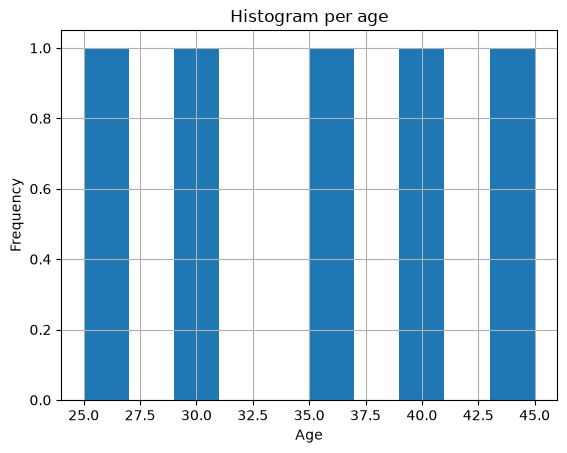

In [46]:
#mathplotlib

import matplotlib.pyplot as plt

df["age"].hist()

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram per age")

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

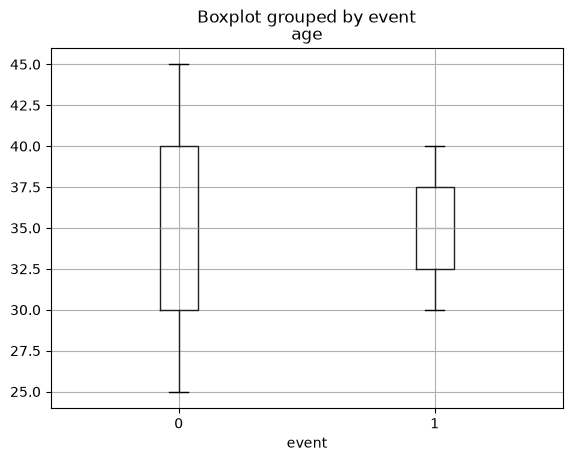

In [47]:
df.boxplot(
    column = "age",
    by="event"
)

plt.show

## excercise 1

In [48]:
rng = np.random.default_rng(seed=42)

n = 100

df = pd.DataFrame({
    "patient_id": range(1,n+1),
    "age": rng.integers(30,85,n),
    "sbp": rng.normal(130,20,size=n),
    "chrl": rng.normal(200,35,size=n),
    "hearth_rate": rng.normal(75,12,size=n)
})

df.head()

,patient_id,age,sbp,chrl,hearth_rate
0,1,34,143.578271,237.309308,109.860806
1,2,72,131.351581,205.496700,60.941200
2,3,66,135.782388,194.447781,70.581013
3,4,54,142.625765,163.752119,79.098667
4,5,53,100.856884,141.386097,95.744372


In [49]:
df["event"] = (
    (df["age"] > 65) & (df["sbp"] > 140)
).astype(int)

df.head(20)

,patient_id,age,sbp,chrl,hearth_rate,event
0,1,34,143.578271,237.309308,109.860806,0
1,2,72,131.351581,205.496700,60.941200,0
2,3,66,135.782388,194.447781,70.581013,0
3,4,54,142.625765,163.752119,79.098667,0
4,5,53,100.856884,141.386097,95.744372,0
5,6,77,123.606576,182.979223,63.157715,0
6,7,34,120.592547,198.117611,72.056666,0
7,8,68,117.222443,261.877547,84.328051,0
8,9,41,124.497155,204.559608,80.217193,0
9,10,35,159.898826,234.395883,70.486127,0


In [50]:
df["event"].value_counts()

event
0    92
1     8
Name: count, dtype: int64

In [51]:
#cuantos pacientes hay?
df["patient_id"].nunique()

100

In [53]:
# cuantos tienen event 1?
df["event"].value_counts()

df.groupby("event")["patient_id"].count()

event
0    92
1     8
Name: patient_id, dtype: int64

In [54]:
# cual es la proporción?
df["event"].value_counts(normalize=True)

event
0    0.92
1    0.08
Name: proportion, dtype: float64

In [55]:
# cual es la edad media?
df["age"].mean()

np.float64(58.49)

In [56]:
# cual es la edad media por clase?
df.groupby("event")["age"].mean()

event
0    57.043478
1    75.125000
Name: age, dtype: float64

In [58]:
# Cuantos tiene presion > 140?
(df["sbp"] > 140).sum()


np.int64(22)

In [59]:
# cual es el coleterol promedio por clase?

df.groupby("event")["chrl"].mean()

event
0    198.763657
1    191.972574
Name: chrl, dtype: float64

In [61]:
# hay duplicados
df.duplicated().sum()

np.int64(0)

In [63]:
# hay missing values?
df.isna().sum()

patient_id     0
age            0
sbp            0
chrl           0
hearth_rate    0
event          0
dtype: int64

In [64]:
# introducción missing values

df.loc[21:32, "chrl"] = np.nan

In [65]:
df.isna().sum()

patient_id      0
age             0
sbp             0
chrl           12
hearth_rate     0
event           0
dtype: int64

In [68]:
df["chrl"] = df["chrl"].fillna(df["chrl"].mean())

In [69]:
df.isna().sum()

patient_id     0
age            0
sbp            0
chrl           0
hearth_rate    0
event          0
dtype: int64

In [72]:
def description_basic(data):
    print("\nhead: \n",df.head())
    print("\ncolumns: \n",df.columns)
    print("\nshape: \n",df.shape)
    print("\ndescription: \n",df.describe())
    print("\nduplicates: \n",df.duplicated().sum())
    print("\nmissing values: \n",df.isna().sum())
    print("\nvalue counts: \n",df["event"].value_counts())


description_basic(df)




head: 
    patient_id  age         sbp        chrl  hearth_rate  event
0           1   34  143.578271  237.309308   109.860806      0
1           2   72  131.351581  205.496700    60.941200      0
2           3   66  135.782388  194.447781    70.581013      0
3           4   54  142.625765  163.752119    79.098667      0
4           5   53  100.856884  141.386097    95.744372      0

columns: 
 Index(['patient_id', 'age', 'sbp', 'chrl', 'hearth_rate', 'event'], dtype='str')

shape: 
 (100, 6)

description: 
        patient_id         age         sbp        chrl  hearth_rate      event
count  100.000000  100.000000  100.000000  100.000000   100.000000  100.00000
mean    50.500000   58.490000  127.474901  197.907354    76.010856    0.08000
std     29.011492   14.950082   17.737987   34.143468    12.050326    0.27266
min      1.000000   32.000000   87.359074  124.844884    44.200099    0.00000
25%     25.750000   47.000000  116.006405  173.674416    69.201437    0.00000
50%     50.500000